# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

**Sumber Dataset**:  
   

1.   Nama dataset :Credit Fraud || Dealing with Imbalanced Datasets
2.   Sumber dataset (https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets)
3.  Deteksi Penipuan Kartu Kredit (Credit Fraud Detector)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library tambahan (jika nanti dibutuhkan untuk preprocessing)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Menyimpan path dataset sesuai dengan lokasi file di Colab
# file_path = '/content/creditcard.csv' #lingkungan calab
# Menyimpan path dataset sesuai dengan lokasi di Google Drive Anda
file_path = '/content/drive/MyDrive/Colab Notebooks/namadataset_raw/creditcard.csv'


# Memuat dataset CSV menjadi dataframe menggunakan pandas
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [12]:
# Menampilkan informasi umum tentang dataset (jumlah baris, kolom, tipe data, dll.)
print("Informasi Dataset:")
df.info()

print("\nDeskripsi Statistik Dataset:")
# Menampilkan ringkasan statistik deskriptif untuk kolom numerik
df.describe()

print("\nJumlah nilai yang hilang per kolom:")
# Memeriksa jumlah nilai yang hilang di setiap kolom
df.isnull().sum()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  floa

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [14]:
# 1. Menghapus data duplikat
print("Jumlah duplikat sebelum dihapus:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Data setelah duplikat dihapus:", df.shape)

# 2. Standarisasi kolom 'Amount' dan 'Time'
# Kita gunakan RobustScaler karena lebih tahan terhadap outlier pada data transaksi finansial
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

# Membuat kolom baru yang sudah di-scale
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Menghapus kolom 'Time' dan 'Amount' yang lama
df.drop(['Time','Amount'], axis=1, inplace=True)

# Memindahkan kolom scaled ke depan agar rapi
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# 3. Memisahkan fitur (X) dan label target (y)
X = df.drop('Class', axis=1)
y = df['Class']

print("\nData Preprocessing Selesai!")
df.head()

Jumlah duplikat sebelum dihapus: 1081
Data setelah duplikat dihapus: (283726, 31)

Data Preprocessing Selesai!


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


Distribusi Kelas:
Class
0    284315
1       492
Name: count, dtype: int64

Persentase Distribusi Kelas:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


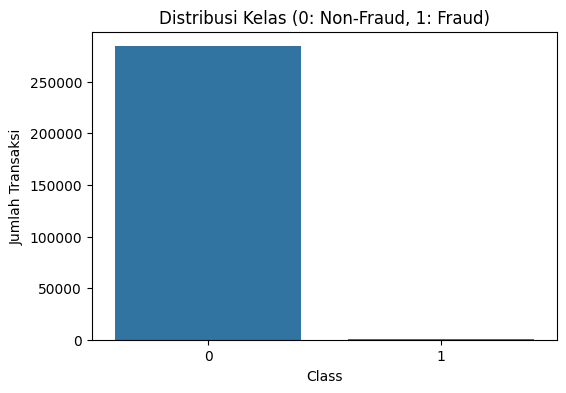

In [13]:
# Memeriksa distribusi kelas target (Class)
print("Distribusi Kelas:")
print(df['Class'].value_counts())

# Menampilkan persentase distribusi kelas
print("\nPersentase Distribusi Kelas:")
print(df['Class'].value_counts(normalize=True) * 100)

# Visualisasi distribusi kelas
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribusi Kelas (0: Non-Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Jumlah Transaksi')
plt.show()

In [15]:
# Tentukan path untuk menyimpan data bersih.
# Buat folder 'namadataset_preprocessing' di Drive Anda atau simpan langsung dengan nama baru.
clean_data_path = '/content/drive/MyDrive/Colab Notebooks/namadataset_raw/creditcard_clean.csv'

# Menggabungkan kembali X dan y sementara untuk disimpan sebagai data siap latih
df_clean = pd.concat([X, y], axis=1)

# Menyimpan dataframe ke dalam format CSV tanpa index
df_clean.to_csv(clean_data_path, index=False)

print("Data bersih berhasil disimpan ke:", clean_data_path)

Data bersih berhasil disimpan ke: /content/drive/MyDrive/Colab Notebooks/namadataset_raw/creditcard_clean.csv
